<a href="https://colab.research.google.com/github/sdf-works/sam-learns-ML/blob/main/02_transformers/labrat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#libraries
import torch, random, numpy as np
seed=42; random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"; device

import math
from dataclasses import dataclass
from typing import Dict, Optional, List, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np, torch

import matplotlib.pyplot as plt

'cpu'

In [2]:
#the tiny, watchable transformer
#I wanna see it's brain work

##this block sets up all the functions needed


@dataclass
class RatConfig:
    d_model: int = 128
    n_layers: int = 2
    n_heads: int = 4
    d_mlp: int = 256
    vocab_size: int = 128          #start with ASCII/byte, can swap later as needed
    max_seq_len: int = 128
    dropout: float = 0.0
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 42


def causal_mask(T: int, device: str):
    # [T, T] with -inf above diagonal
    mask = torch.full((T, T), float("-inf"), device=device)
    return torch.triu(mask, diagonal=1)


class Attention(nn.Module):
    def __init__(self, cfg: RatConfig):
        super().__init__()
        self.cfg = cfg
        h, d = cfg.n_heads, cfg.d_model
        assert d % h == 0, "d_model must be divisible by n_heads"
        self.d_head = d // h

        self.W_qkv = nn.Linear(d, 3 * d, bias=False)
        self.W_o   = nn.Linear(d, d, bias=False)
        self.drop  = nn.Dropout(cfg.dropout)

    def forward(
        self,
        x: torch.Tensor,                #[B, T, d_model] #B: batch size, T: sequence length, d_model: dims
        mask: torch.Tensor,             #[T, T], causal
        record: bool = False,
        trace: Optional[Dict] = None,
        layer_idx: int = 0,
        head_mask: Optional[torch.Tensor] = None,  #[n_heads] 1=keep, 0=ablate
    ):
        B, T, D = x.shape
        H, Dh = self.cfg.n_heads, self.d_head

        qkv = self.W_qkv(x)  #[B, T, 3D]
        q, k, v = qkv.chunk(3, dim=-1)

        #[B, T, H, Dh] #H: attention heads
        q = q.view(B, T, H, Dh)
        k = k.view(B, T, H, Dh)
        v = v.view(B, T, H, Dh)

        #attention scores: [B, H, T, T]
        att = torch.einsum("bthd,bshd->bh ts", q, k) / math.sqrt(Dh)
        att = att + mask  #causal
        att_weights = att.softmax(dim=-1)  #[B, H, T, T]
        att_weights = self.drop(att_weights)

        #optional head ablation (broadcast over batch & time dims)
        if head_mask is not None:
            hm = head_mask.view(1, H, 1, 1)
            att_weights = att_weights * hm

        #attn output: [B, T, H, Dh] -> [B, T, D]
        out = torch.einsum("bhts, bshd -> bthd", att_weights, v).reshape(B, T, D)
        out = self.W_o(out)
        out = self.drop(out)

        if record and trace is not None:
            key = f"layer_{layer_idx}"
            bucket = trace.setdefault(key, {})
            bucket["attn_q"] = q.detach().cpu()
            bucket["attn_k"] = k.detach().cpu()
            bucket["attn_v"] = v.detach().cpu()
            bucket["attn_weights"] = att_weights.detach().cpu()
            bucket["attn_out"] = out.detach().cpu()

        return out


class MLP(nn.Module):
    def __init__(self, cfg: RatConfig):
        super().__init__()
        self.cfg = cfg
        self.fc1 = nn.Linear(cfg.d_model, cfg.d_mlp)
        self.fc2 = nn.Linear(cfg.d_mlp, cfg.d_model)
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, x, record=False, trace=None, layer_idx=0):
        pre = self.fc1(x)                       #[B, T, d_mlp]
        act = F.gelu(pre)
        out = self.fc2(act)                     #[B, T, d_model]
        out = self.drop(out)
        if record and trace is not None:
            bucket = trace.setdefault(f"layer_{layer_idx}", {})
            bucket["mlp_pre"] = pre.detach().cpu()
            bucket["mlp_act"] = act.detach().cpu()
            bucket["mlp_out"] = out.detach().cpu()
        return out


class Block(nn.Module):
    def __init__(self, cfg: RatConfig, idx: int):
        super().__init__()
        self.cfg = cfg
        self.idx = idx
        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.attn = Attention(cfg)
        self.ln2 = nn.LayerNorm(cfg.d_model)
        self.mlp = MLP(cfg)

    def forward(
        self, x, mask, record=False, trace=None, head_mask=None
    ):
        #Pre-attn residual
        x_ln = self.ln1(x)
        attn_out = self.attn(
            x_ln, mask, record=record, trace=trace, layer_idx=self.idx, head_mask=head_mask
        )
        x = x + attn_out
        if record and trace is not None:
            bucket = trace.setdefault(f"layer_{self.idx}", {})
            bucket["resid_post_attn"] = x.detach().cpu()

        #MLP
        x_ln2 = self.ln2(x)
        mlp_out = self.mlp(x_ln2, record=record, trace=trace, layer_idx=self.idx)
        x = x + mlp_out
        if record and trace is not None:
            bucket = trace.setdefault(f"layer_{self.idx}", {})
            bucket["resid_post_mlp"] = x.detach().cpu()

        return x


class LabRatTransformer(nn.Module):
    def __init__(self, cfg: RatConfig):
        super().__init__()
        torch.manual_seed(cfg.seed)
        self.cfg = cfg

        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.pos_emb = nn.Embedding(cfg.max_seq_len, cfg.d_model)

        self.blocks = nn.ModuleList([Block(cfg, i) for i in range(cfg.n_layers)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.unembed = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)

        self.register_buffer("mask_cache", causal_mask(cfg.max_seq_len, cfg.device))

    def forward(
        self,
        input_ids: torch.Tensor,                 #[B, T]
        record: bool = False,
        head_masks: Optional[List[torch.Tensor]] = None,  #per-layer [n_heads]
    ) -> Tuple[torch.Tensor, Dict]:
        """
        Returns:
          logits: [B, T, vocab]
          trace: dict of captured activations (if record=True)
        """
        B, T = input_ids.shape
        assert T <= self.cfg.max_seq_len, "Sequence too long"

        device = input_ids.device
        pos = torch.arange(T, device=device)
        x = self.tok_emb(input_ids) + self.pos_emb(pos)[None, :, :]  #[B, T, d]
        trace: Dict = {}

        #initial residual
        if record:
            trace["resid_pre"] = x.detach().cpu()

        mask = self.mask_cache[:T, :T]

        for i, block in enumerate(self.blocks):
            hm = None
            if head_masks is not None and head_masks[i] is not None:
                hm = head_masks[i].to(device)  #[n_heads]
            x = block(x, mask, record=record, trace=trace, head_mask=hm)

        x = self.ln_f(x)
        if record:
            trace["resid_post_all"] = x.detach().cpu()

        logits = self.unembed(x)

        if record:
            trace["logits_final"] = logits.detach().cpu()

        return logits, trace

#if the model had to guess the next token right now, what would it guess?

    @torch.no_grad()
    def logit_lens(self, input_ids: torch.Tensor) -> Dict[str, torch.Tensor]:
        """
        Projects intermediate residual streams to vocab space.
        Returns dict: event order through layers -> [B, T, vocab]
        """
        B, T = input_ids.shape
        device = input_ids.device
        pos = torch.arange(T, device=device)
        x = self.tok_emb(input_ids) + self.pos_emb(pos)[None, :, :]

        outs = {"layer_-1": self.unembed(self.ln_f(x)).detach().cpu()}  #embed-only view
        mask = self.mask_cache[:T, :T]

        for i, block in enumerate(self.blocks):
            x = block.ln1(x)
            attn_out = block.attn(x, mask, record=False, trace=None, layer_idx=i)
            x = x + attn_out
            x = x + block.mlp(block.ln2(x))
            outs[f"layer_{i}"] = self.unembed(self.ln_f(x)).detach().cpu()

        return outs

In [5]:
#boot up ritual + sanity check
cfg = RatConfig(d_model=128, n_layers=2, n_heads=4, d_mlp=256, vocab_size=128, max_seq_len=128, dropout=0.0)
model = LabRatTransformer(cfg).to(cfg.device)
sum(p.numel() for p in model.parameters()), cfg

(313344,
 RatConfig(d_model=128, n_layers=2, n_heads=4, d_mlp=256, vocab_size=128, max_seq_len=128, dropout=0.0, device='cpu', seed=42))

In [6]:
#test drive
data = torch.tensor(list(text.encode("utf-8")), dtype=torch.long, device=cfg.device)
B,T = 2, 32
x = torch.randint(0, cfg.vocab_size, (B,T), device=cfg.device)
logits, trace = model(x, record=True)
print("logits:", logits.shape)     # [B,T,vocab]
print("trace keys:", list(trace.keys())[:6])
print("layer_0 keys:", list(trace["layer_0"].keys()))

logits: torch.Size([2, 32, 128])
trace keys: ['resid_pre', 'layer_0', 'layer_1', 'resid_post_all', 'logits_final']
layer_0 keys: ['attn_q', 'attn_k', 'attn_v', 'attn_weights', 'attn_out', 'resid_post_attn', 'mlp_pre', 'mlp_act', 'mlp_out', 'resid_post_mlp']


In [7]:
#now teach the model something, just a lil cheeky phrase
text = ("all models are wrong but some are useful\n"
        "lab rats are adorable and interpretable\n") * 200

# byte-level “tokenizer”
data = torch.tensor(list(text.encode("utf-8")), dtype=torch.long, device=cfg.device)

def get_batch(seq_len=64, batch_size=32):
    ix = torch.randint(0, len(data)-seq_len-1, (batch_size,), device=cfg.device)
    x = torch.stack([data[i:i+seq_len] for i in ix])
    y = torch.stack([data[i+1:i+seq_len+1] for i in ix])
    return x, y

In [8]:
#now training the model (training loop)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

def step(seq_len=64, batch=64):
    model.train()
    x,y = get_batch(seq_len, batch)
    logits,_ = model(x, record=False)
    loss = F.cross_entropy(logits.reshape(-1, cfg.vocab_size), y.reshape(-1))
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    return float(loss)

for it in range(200):
    loss = step()
    if (it+1)%20==0: print(f"iter {it+1:03d} | loss {loss:.3f}") #always want to see what is going on

/tmp/ipython-input-2681576764.py:10: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  return float(loss)


iter 020 | loss 3.549
iter 040 | loss 2.532
iter 060 | loss 2.042
iter 080 | loss 1.724
iter 100 | loss 1.498
iter 120 | loss 1.337
iter 140 | loss 1.167
iter 160 | loss 0.941
iter 180 | loss 0.729
iter 200 | loss 0.545


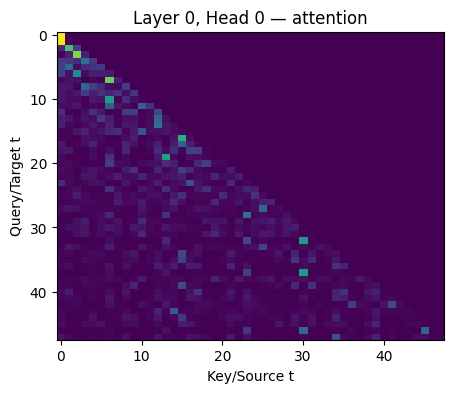

layer_-1 [('g', 1.8071036338806152), ('t', 1.6802959442138672), ('\n', 1.361924648284912), ('E', 1.202290654182434), ('\x02', 1.0991184711456299)]
layer_0 [(' ', 3.961798667907715), ('l', 3.494420051574707), ('\n', 3.463691473007202), ('s', 2.875088691711426), ('r', 1.5535178184509277)]
layer_1 [(' ', 7.252490043640137), ('l', 5.379263877868652), ('s', 4.902807235717773), ('\n', 2.5820956230163574), ('f', 1.6108155250549316)]


In [9]:
#now plots!
model.eval()
x,_ = get_batch(seq_len=48, batch_size=1)
_, trace = model(x, record=True)

att = trace["layer_0"]["attn_weights"][0]  # [H, T, T] on CPU
plt.figure(figsize=(5,4))
plt.imshow(att[0].numpy(), aspect='auto')
plt.title("Layer 0, Head 0 — attention"); plt.xlabel("Key/Source t"); plt.ylabel("Query/Target t"); plt.show()

lens = model.logit_lens(x)
for k in ["layer_-1","layer_0","layer_1"]:
    ll = lens[k][0,-1]  # last position logits
    topv, topi = torch.topk(ll, 5)
    toks = [bytes([i]).decode('utf-8', errors='ignore') or f"<{int(i)}>" for i in topi]
    print(k, list(zip(toks, [float(v) for v in topv])))

Attention heatmap: This graph shows how the model decides what parts of the phrase to pay attention to when predicting the next character.

Query (rows): where the model is right now, trying to decide what letter is coming next

Key (column): earlier letters that the model can look for to help decide what letter is next

A bright pixel shows what the model looked at while predicting the next letter.

In [12]:
#seeing what happens when we remove certain information
#mask out one head in layer 0 (e.g., head 0 -> 0)
head_masks = [torch.tensor([0,1,1,1]), None]  #layer0: drop head0; layer1: keep all
logits_abl, _ = model(x, record=False, head_masks=head_masks)

def ppl(logits, y):
    loss = F.cross_entropy(logits.reshape(-1, cfg.vocab_size), y.reshape(-1))
    return float(torch.exp(loss))

y = x[:,1:]
ppl_full = ppl((model(x, record=False)[0])[:,:-1], y)
ppl_drop = ppl(logits_abl[:,:-1], y)
print(f"ppl full={ppl_full:.2f} | drop head0={ppl_drop:.2f}")

ppl full=1.71 | drop head0=2.66


In [13]:
@torch.no_grad()
def eval_perplexity(model, get_batch, seq_len=64, batches=50):
    model.eval()
    losses = []
    for _ in range(batches):
        x, y = get_batch(seq_len, 64)           # adjust batch size if needed
        logits, _ = model(x, record=False)
        loss = F.cross_entropy(
            logits[:, :-1, :].reshape(-1, model.cfg.vocab_size),
            y[:, :-1].reshape(-1)
        )
        losses.append(float(loss))
    mean_loss = float(np.mean(losses))
    return float(np.exp(mean_loss))   # perplexity

In [14]:
@torch.no_grad()
def head_importance_matrix(model, get_batch, seq_len=64, batches=25):
    cfg = model.cfg
    base_ppl = eval_perplexity(model, get_batch, seq_len, batches)
    L, H = cfg.n_layers, cfg.n_heads

    delta = np.zeros((L, H), dtype=np.float32)

    for layer in range(L):
        for head in range(H):
            # Build masks: keep all heads except the target one
            head_masks = []
            for li in range(L):
                if li == layer:
                    m = torch.ones(H, device=cfg.device)
                    m[head] = 0.0          # ablate this head
                    head_masks.append(m)
                else:
                    head_masks.append(None)

            # Evaluate perplexity with this head ablated
            model.eval()
            losses = []
            for _ in range(batches):
                x, y = get_batch(seq_len, 64)
                logits, _ = model(x, record=False, head_masks=head_masks)
                loss = F.cross_entropy(
                    logits[:, :-1, :].reshape(-1, cfg.vocab_size),
                    y[:, :-1].reshape(-1)
                )
                losses.append(float(loss))
            ppl_drop = float(np.exp(np.mean(losses)))

            delta[layer, head] = ppl_drop - base_ppl  # Δppl (higher = more important)

    return base_ppl, delta

In [15]:
base_ppl, delta = head_importance_matrix(model, get_batch, seq_len=64, batches=20)
print(f"Baseline perplexity: {base_ppl:.3f}")
delta

Baseline perplexity: 1.705


array([[0.63291395, 0.24076428, 0.4675554 , 0.21271153],
       [0.22379395, 0.2525316 , 0.22128354, 0.23757741]], dtype=float32)

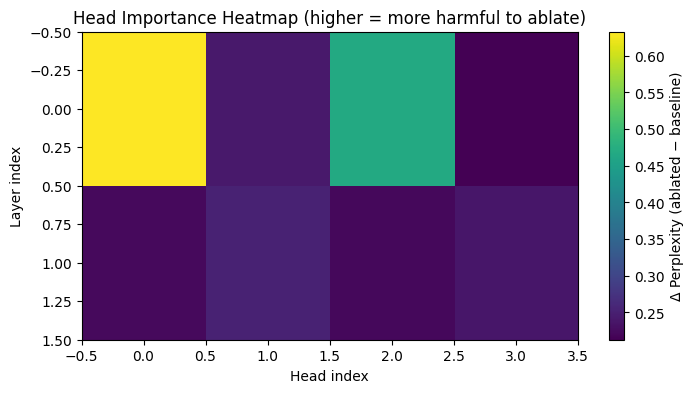

In [16]:
plt.figure(figsize=(8, 4))
im = plt.imshow(delta, aspect='auto')
plt.colorbar(im, label="Δ Perplexity (ablated − baseline)")
plt.xlabel("Head index")
plt.ylabel("Layer index")
plt.title("Head Importance Heatmap (higher = more harmful to ablate)")
plt.show()

This is like a group project in your gen-ed classes. Some of the heads are doing more work (the brighter ones), so if they don't show up for class, it's a lot more distruptive.

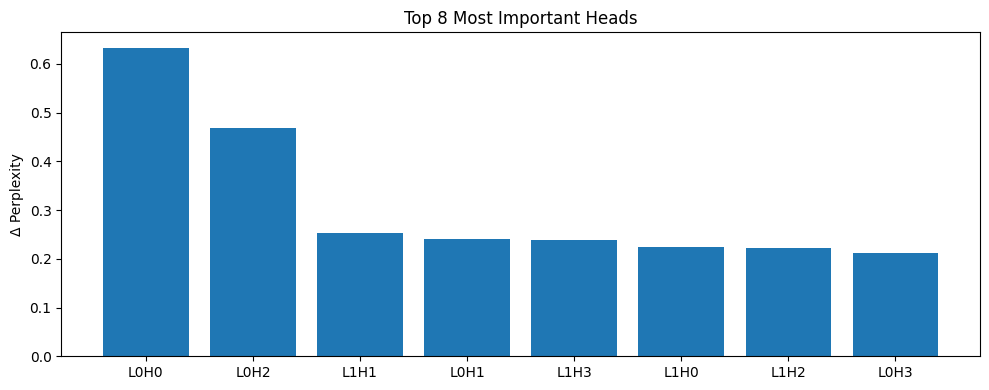

In [17]:
L, H = delta.shape
flat = delta.flatten()
order = np.argsort(flat)[::-1]  # descending by importance
top_k = 8                       # change as you like

labels, values = [], []
for idx in order[:top_k]:
    layer = idx // H
    head  = idx % H
    labels.append(f"L{layer}H{head}")
    values.append(flat[idx])

plt.figure(figsize=(10, 4))
plt.bar(np.arange(top_k), values)
plt.xticks(np.arange(top_k), labels, rotation=0)
plt.ylabel("Δ Perplexity")
plt.title(f"Top {top_k} Most Important Heads")
plt.tight_layout()
plt.show()

Continuing with the class project analogy, this is like being able to see the efforts of each of the students. The first two are doing more work than the rest.

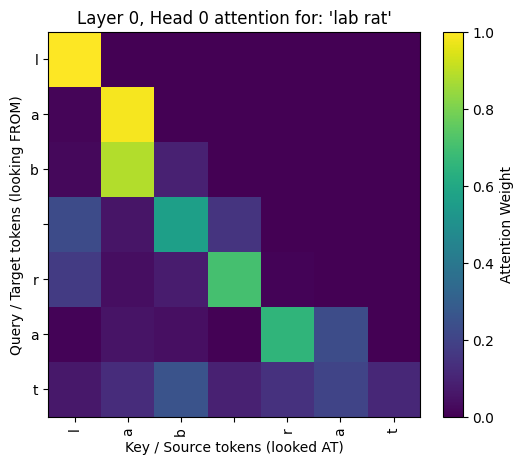

In [21]:
#now looking at the heatmap for a specific phrase

def plot_attention_for_prompt(model, prompt, layer=0, head=0):
    # Encode string to bytes (ASCII/UTF-8), shape [1, T]
    tokens = torch.tensor([list(prompt.encode("utf-8"))], device=model.cfg.device)

    # Run with tracing
    _, trace = model(tokens, record=True)
    attn = trace[f"layer_{layer}"]["attn_weights"][0]  # [H, T, T] for batch 0
    attn = attn[head].numpy()  # select one head [T, T]

    # Decode bytes back to characters for labels
    toks = [chr(t) if 32 <= t < 127 else f"<{t}>" for t in tokens[0].tolist()]

    # Plot
    plt.figure(figsize=(6,5))
    plt.imshow(attn, cmap="viridis", aspect="auto")
    plt.colorbar(label="Attention Weight")
    plt.xticks(range(len(toks)), toks, rotation=90)
    plt.yticks(range(len(toks)), toks)
    plt.xlabel("Key / Source tokens (looked AT)")
    plt.ylabel("Query / Target tokens (looking FROM)")
    plt.title(f"Layer {layer}, Head {head} attention for: '{prompt}'")
    plt.show()

plot_attention_for_prompt(model, "lab rat", layer=0, head=0)

Now when we take a specific example phrase, we can see where the model is putting it's attention within the phrase. For example, at the "b" in "lab", the model paid a lot of attention back to the "a" in lab.

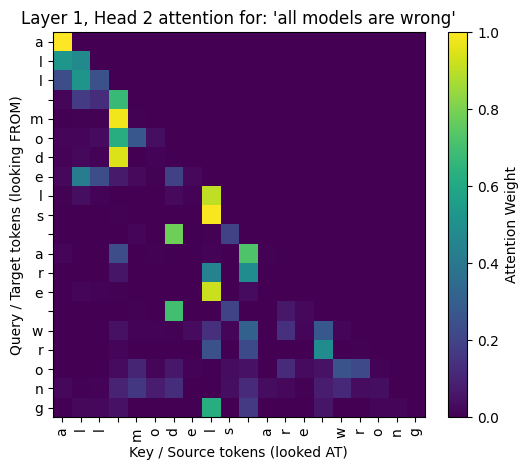

In [22]:
plot_attention_for_prompt(model, "all models are wrong", layer=1, head=2)

A longer phrase. This is where things start to get really interesing. We see that the model refers back to the "l" in "models" often throughout the phrase prediction process. We also see that after that second space, the characters aren't super important (but the third space is). The earlier tokens are referred to a lot in the earlier stages and then less so as the model moves along the phrase.

In [23]:
#checking attention coverage for each part of the model
def attention_coverage(model, prompt, layer=None, head=None, normalize=True):
    """
    Returns:
      toks: list[str]  — printable labels for each byte/token
      cov:  np.ndarray — attention coverage per token position (shape [T])

    coverage[j] = sum over all later queries i of attention weight A[i, j]
    (i.e., how much later tokens look back at position j).
    """
    # Encode prompt to bytes (works with vocab_size=128 byte-level)
    tokens = torch.tensor([list(prompt.encode("utf-8"))], device=model.cfg.device)
    B, T = tokens.shape

    # Run model with recording on
    _, trace = model(tokens, record=True)

    cov = np.zeros(T, dtype=np.float64)

    # Which layers/heads to use
    layers = range(model.cfg.n_layers) if layer is None else [layer]

    for l in layers:
        att = trace[f"layer_{l}"]["attn_weights"][0].cpu().numpy()  # [H, T, T] for batch 0
        H = att.shape[0]
        heads = range(H) if head is None else [head]
        for h in heads:
            A = att[h]  # [T, T], rows=queries (target positions), cols=keys (source positions)
            # Because of causal masking, A[i, j] = 0 for j > i, so summing over rows is “later queries”
            cov += A.sum(axis=0)  # sum attention received by each source column across all queries

    if normalize and cov.sum() > 0:
        cov = cov / cov.sum()

    # Pretty-ish labels for bytes (printable ASCII; else show <num>)
    toks = [chr(t) if 32 <= t < 127 else f"<{int(t)}>" for t in tokens[0].tolist()]
    return toks, cov

In [24]:
def plot_wheel_of_fortune(toks, cov, title="Attention Coverage (who the model keeps looking at)"):
    T = len(toks)
    x = np.arange(T)
    plt.figure(figsize=(max(8, T*0.4), 4))
    plt.bar(x, cov)  # no explicit colors per your style guide
    plt.xticks(x, toks, rotation=90)
    plt.ylabel("Normalized attention coverage")
    plt.title(title)
    plt.tight_layout()
    plt.show()

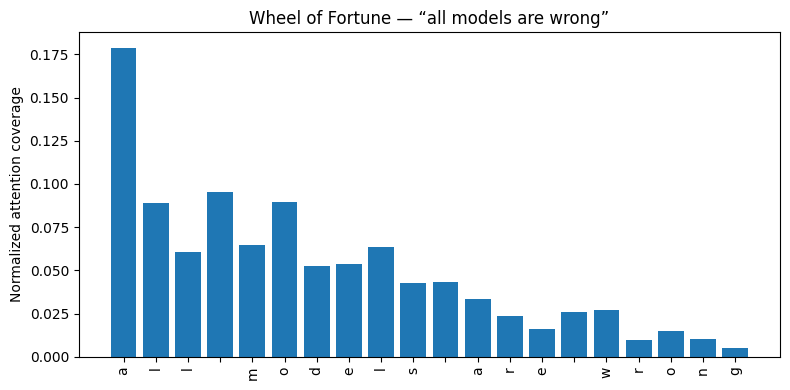

In [26]:
prompt = "all models are wrong"
toks, cov = attention_coverage(model, prompt)  # sum over all layers & heads
plot_wheel_of_fortune(toks, cov, title=f"Wheel of Fortune — “{prompt}”")

I like to think of this as "Wheel of Fortune". Some letteres in the puzzle are really important and some are not. The spaces are also crucial.

In [27]:
#just want to see what the model does if we give it garbage in
#garbage comes out lol
@torch.no_grad()
def generate(model, prompt, max_new_tokens=100, temperature=0.8):
    # encode prompt as bytes
    tokens = torch.tensor([list(prompt.encode("utf-8"))], device=model.cfg.device)
    generated = tokens.clone()

    for _ in range(max_new_tokens):
        logits, _ = model(generated[:, -model.cfg.max_seq_len:], record=False)
        next_logits = logits[0, -1] / temperature
        probs = torch.softmax(next_logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        generated = torch.cat([generated, next_token.unsqueeze(0)], dim=1)

    return bytes(generated[0].tolist()).decode("utf-8", errors="ignore")

print(generate(model, "all mo", max_new_tokens=40))
print(generate(model, "but so", max_new_tokens=40))

all more useful
lablsqre s are us re rab us ar
but some arable able and more are atatere ante


In [28]:
#more trying to observe the brain of the model
@torch.no_grad()
def generate_with_trace(model, prompt, max_new_tokens=80, temperature=0.8, topk=5):
    # encode prompt as bytes
    ctx = torch.tensor([list(prompt.encode("utf-8"))], device=model.cfg.device)
    out = ctx.clone()

    trace = {
        "prompt": prompt,
        "steps": []  # list of dicts: {step, next_id, next_char, entropy, topk_ids, topk_probs}
    }

    for step in range(max_new_tokens):
        # forward last window
        logits, _ = model(out[:, -model.cfg.max_seq_len:], record=False)
        logits = logits[0, -1] / max(1e-6, temperature)
        probs = torch.softmax(logits, dim=-1)

        # entropy in nats
        entropy = -(probs * torch.clamp(probs.log(), min=-30)).sum().item()

        # top-k for inspection (probs as Python floats)
        tk_probs, tk_ids = torch.topk(probs, k=min(topk, model.cfg.vocab_size))
        tk_ids = tk_ids.tolist()
        tk_probs = tk_probs.tolist()

        # sample next token (multinomial)
        next_id = torch.multinomial(probs, num_samples=1).item()
        out = torch.cat([out, torch.tensor([[next_id]], device=out.device)], dim=1)

        # byte → printable character
        def printable(i):
            try:
                ch = bytes([i]).decode("utf-8")
                if 32 <= i < 127:
                    return ch
            except:
                pass
            return f"<{i}>"

        step_rec = {
            "step": step,
            "next_id": next_id,
            "next_char": printable(next_id),
            "entropy": entropy,
            "topk_ids": tk_ids,
            "topk_chars": [printable(i) for i in tk_ids],
            "topk_probs": tk_probs,
        }
        trace["steps"].append(step_rec)

    # decoded text
    decoded = bytes(out[0].tolist()).decode("utf-8", errors="ignore")
    trace["decoded"] = decoded
    return decoded, trace

In [29]:
def plot_entropy_trace(trace, title_prefix="Entropy trace"):
    steps = trace["steps"]
    ent = [s["entropy"] for s in steps]
    chars = [s["next_char"] for s in steps]

    plt.figure(figsize=(max(8, len(ent)*0.35), 4))
    plt.plot(range(len(ent)), ent, marker="o")
    plt.xticks(range(len(chars)), chars, rotation=90)
    plt.ylabel("Entropy (nats)")
    plt.xlabel("Generated token")
    plt.title(f"{title_prefix} — prompt: “{trace['prompt']}”")
    plt.tight_layout()
    plt.show()

all models are wrondode-e ing busome ut are ab


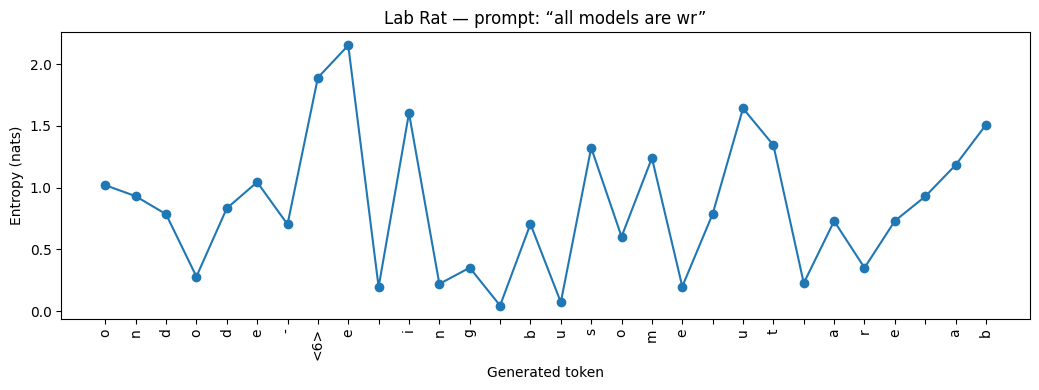

In [30]:
decoded, tr = generate_with_trace(model, "all models are wr", max_new_tokens=30, temperature=0.8, topk=5)
print(decoded)
plot_entropy_trace(tr, title_prefix="Lab Rat")

Understanding the nonsense can be just as interesting (and maybe more valuable). This shows how certain the model is in it's next guess. Spaces are low entropy becuse a letter comes next. That is always true. Everything else is a little questionable. It's interesting to see how entropy drops in a grouping it's pretty sure about (i -> n -> g), which is commonly true but not found in the training dataset!